# Data preparation first step of Stage 1 for buiding an llm
the process involves 2 stages: 1 building the llm and second one Foundation Model
## Stage 1
### Step 1 Data preparation 

In [4]:
with open("training_text.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
print("Total number of character: ", len(raw_text))
print(raw_text[:99])

Total number of character:  20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [5]:
import re
text = "hello, workd. this is a test"
result = re.split(r'(\s)', text)
print(result)

['hello,', ' ', 'workd.', ' ', 'this', ' ', 'is', ' ', 'a', ' ', 'test']


In [6]:
result = re.split(r'([,.]|\s)', text)
print(result)

['hello', ',', '', ' ', 'workd', '.', '', ' ', 'this', ' ', 'is', ' ', 'a', ' ', 'test']


In [7]:
result = [item for item in result if item.strip()]
print(result)

['hello', ',', 'workd', '.', 'this', 'is', 'a', 'test']


In [8]:
text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip() ]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


In [9]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(len(preprocessed))

4690


In [10]:
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [11]:
# converting tokens into token ids
# tokenizer breaks donwn the input text into tokens
# Each unique token is added to the vocabulary in alphabetical order.

all_words = sorted(set(preprocessed))
vocab_size = len(all_words)
print(vocab_size)
print(all_words[:30])

1130
['!', '"', "'", '(', ')', ',', '--', '.', ':', ';', '?', 'A', 'Ah', 'Among', 'And', 'Are', 'Arrt', 'As', 'At', 'Be', 'Begin', 'Burlington', 'But', 'By', 'Carlo', 'Chicago', 'Claude', 'Come', 'Croft', 'Destroyed']


In [12]:
# create a dictionary, keys are token string and values are token id
vocab = { token: integer for integer, token in enumerate(all_words)}
for i, item in enumerate(vocab.items()):
    print(item)
    if i >=  50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


In [13]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s, i in vocab.items()}

    
    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        ids = [self.str_to_int[item] for item in preprocessed ]
        return ids
    
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # removes spaces before punctuation marks
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text


In [14]:
tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know," 
       Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [15]:
print(tokenizer.decode(ids))

" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.


In [ ]:
# text = "Hello, do you like tea?"
# print(tokenizer.encode(text))

In [16]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = { s:i for i,s in enumerate(all_tokens) }
print(len(vocab))

1132


In [17]:
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [18]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s, i in vocab.items() }

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        preprocessed = [item if item in self.str_to_int else "<|unk|>" for item in preprocessed]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
    
    def decode(self, ids):
        text = " ".join([self.int_to_str[id] for id in ids])
        
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text


In [19]:
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join((text1, text2))
print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [20]:
tokenizer = SimpleTokenizerV2(vocab)
print(tokenizer.encode(text))

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]


In [21]:
print(tokenizer.decode(tokenizer.encode(text)))

<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


In [22]:
from importlib.metadata import version
import tiktoken
print("tiktoken version:", version("tiktoken"))

tiktoken version: 0.7.0


In [23]:
tokenizer = tiktoken.get_encoding("gpt2")


In [24]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [25]:
strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


In [26]:
text = "Akwirw ier"
ids = tokenizer.encode(text)
print(ids)
text_r = tokenizer.decode(ids)
print(text_r)

[33901, 86, 343, 86, 220, 959]
Akwirw ier


### Data samplimg with a sliding window

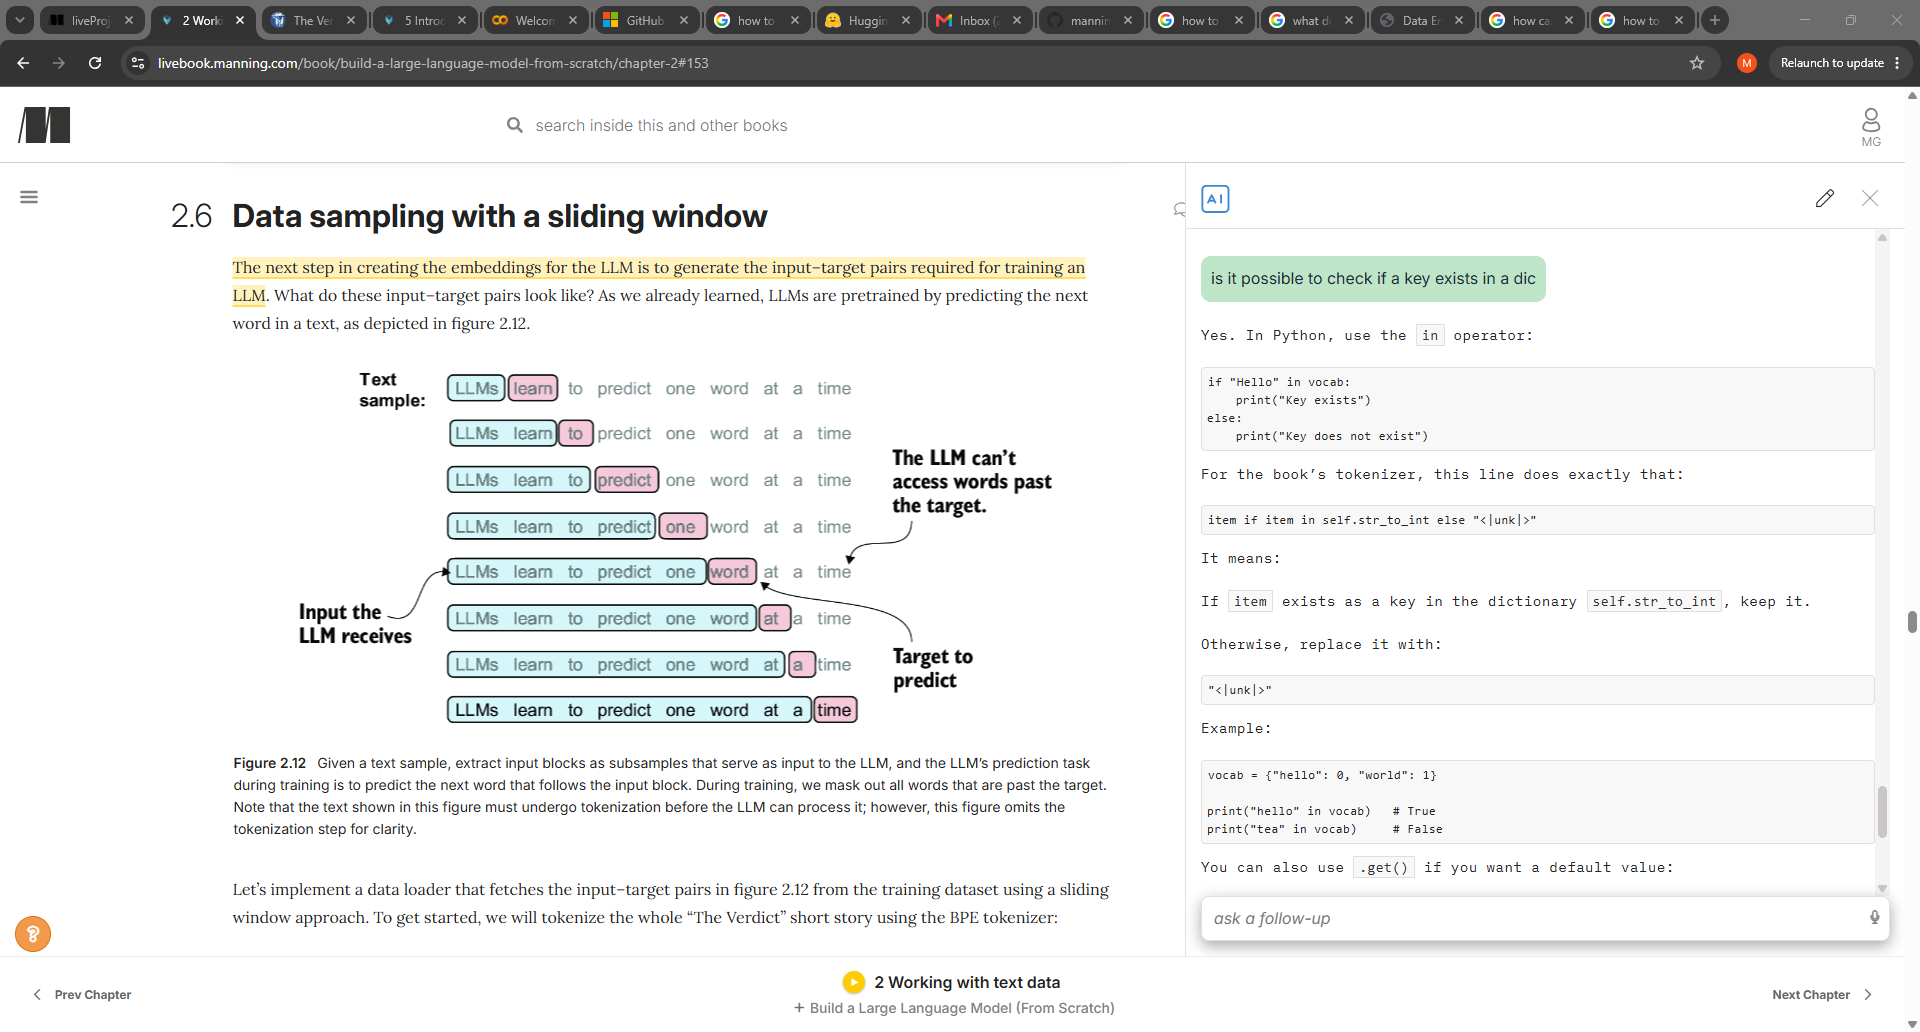

In [27]:
with open("training_text.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)

In [28]:
print(enc_text[-5:])
print(len(enc_text))

[674, 1611, 286, 1242, 526]
5145


In [29]:
enc_sample = enc_text[50:]

In [30]:
context_size = 4
x = enc_sample[:context_size]
y = enc_sample[2:context_size + 2]
print(f"x: {x}")
print(f"y:            {y}")

x: [290, 4920, 2241, 287]
y:            [2241, 287, 257, 4489]


In [31]:
for i in range(1, context_size + 1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


In [32]:
for i in range(1, context_size + 1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(tokenizer.decode(context), "----->", tokenizer.decode([desired]))

 and ----->  established
 and established ----->  himself
 and established himself ----->  in
 and established himself in ----->  a


In [33]:
import torch
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []
        print(max_length, stride)
        token_ids = tokenizer.encode(txt)
        # stride determinates if each cycle overloap or not
        for i in range(0, len(token_ids) - max_length, stride):
            # eg cycle 1: starts at 0 ends at max_length
            # if max_length = 4
            # then starts at 0 and ends at 4
            input_chunk = token_ids[i: i + max_length]

            # eg cycle 1: starts at i = 0 and max_length = 4
            # starts = 0 + 1 = 1
            # ends = 0 + 4 + 1 = 5
            # items in list 1: [0,1,2,3]
            # items in list 2:   [1,2,3,4]
            # overlaps it is eaqul to max_length - 1 = 3

            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    
    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [34]:

def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, suffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=suffle,
        drop_last=drop_last,
        num_workers=num_workers
    )
    return dataloader 

In [35]:
with open("training_text.txt", "r", encoding="utf-8") as file:
    txt = file.read()

dataloader = create_dataloader_v1(txt, batch_size=1, max_length=4, stride=4, suffle=False)
data_iter = iter(dataloader)
first_batch = next(data_iter)
second_batch = next(data_iter)
print(first_batch)
print(second_batch)


4 4
[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]
[tensor([[1807, 3619,  402,  271]]), tensor([[ 3619,   402,   271, 10899]])]


# Creating token embeddings

In [36]:
input_ids = torch.tensor([2, 3, 5, 1])
vocab_size = 6
output_dim = 3

In [37]:
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer.weight)


Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [38]:
print(embedding_layer(torch.tensor([0])))


tensor([[ 0.3374, -0.1778, -0.1690]], grad_fn=<EmbeddingBackward0>)


In [39]:
print(embedding_layer(torch.tensor(input_ids)))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


C:\Users\CF2\AppData\Local\Temp\ipykernel_2572\3846183200.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print(embedding_layer(torch.tensor(input_ids)))


# Encoding word positions


In [40]:
vocab_size = 50_257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)


In [41]:
# batch of 8, each input and target sets, contains 4 tokens and the embeddings 
# for each token is 256

max_length = 4
dataloader = create_dataloader_v1(txt, batch_size=8, max_length=max_length, stride=max_length, suffle=False)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Token Ids: \n", inputs)
print("\n Input shape \n", inputs.shape)

4 4
Token Ids: 
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

 Input shape 
 torch.Size([8, 4])


In [42]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)


torch.Size([8, 4, 256])


In [43]:
context_lengh = max_length
pos_embedding_layer = torch.nn.Embedding(context_lengh, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_lengh))
print(pos_embeddings.shape)


torch.Size([4, 256])


In [ ]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])
